In [1]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.scba import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *
from triqs.lattice.tight_binding import dos

dim = 3
save_dir = f'data/{dim}d/rpa_ba'

Starting serial run at: 2026-05-04 00:04:01.699319


Gamma =  0.1


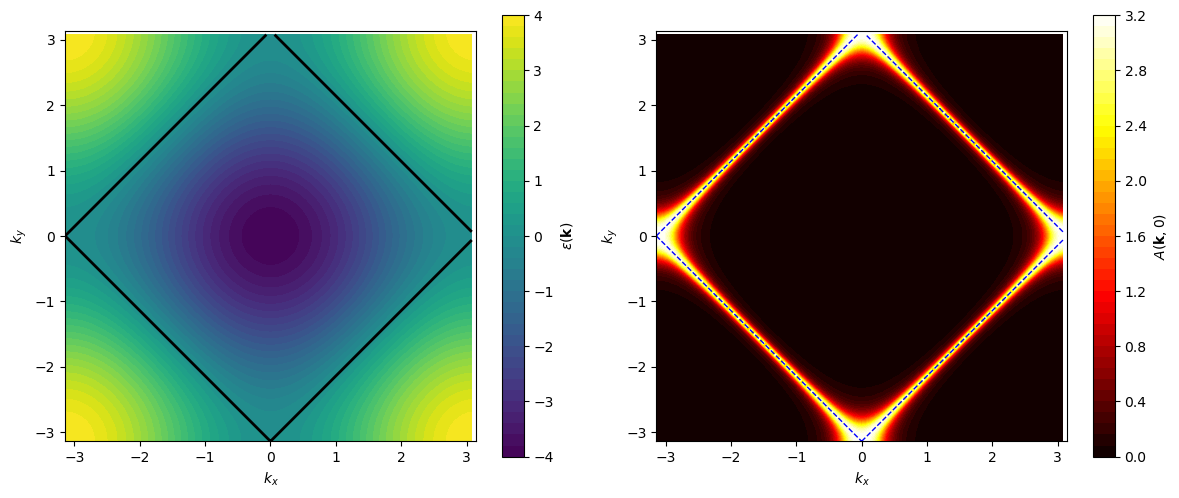

In [2]:
square = LATTICE(dim=2, tp=0.)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi


v = 1
rho = dos(square.H_r.tb, nk, n_eps=100, name='')[0]
rho_0 = np.interp(0.0, rho.eps, rho.rho)
Gamma = np.pi * v**2 * rho_0
Gamma = 0.1
print('Gamma = ', Gamma)

T = 0.1
n = 1
mu = get_mu(e_k=square.e_k, n_goal=n, beta=1/T)
Ak0 = (1/np.pi) * Gamma / (Gamma**2 + (eps - mu)**2)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


0.0
0.0
0.0
0.0
0.0
0.0
0.0
-1.7763568394002505e-15
-1.7763568394002505e-15
0.0


[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    3.6s finished


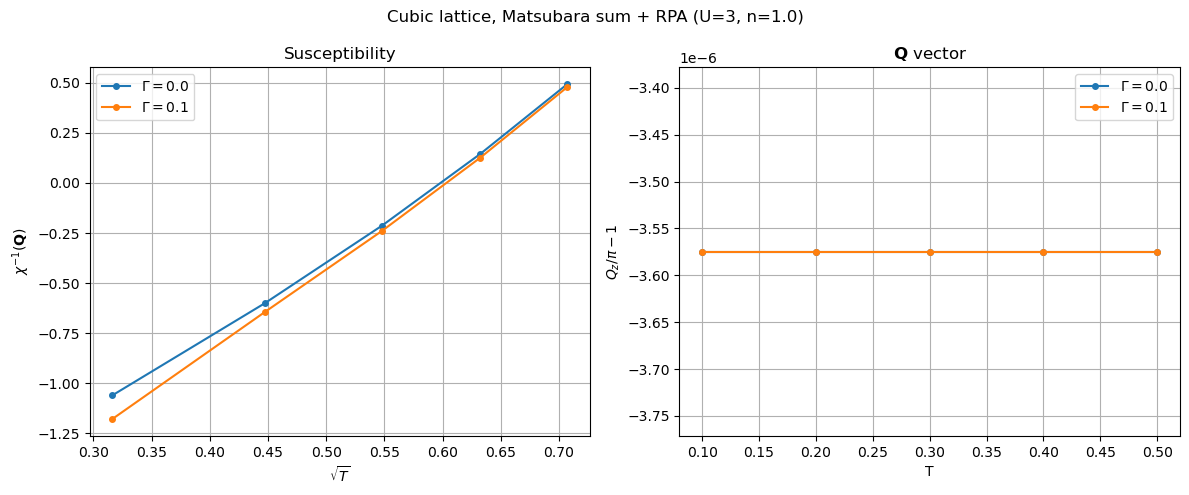

In [8]:
U = 3
n = 1.
T_list = np.linspace(0.1, 0.5, 5)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara sum + RPA (U={U}, n={n})'

nk = 50

Gamma_list = [0., 0.1]
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'S_iwk_list': [-1j*Gamma]*len(T_list), 'nk_avg': (1,1), 'method': 'lindhard', 'n_iw_extr': True, 'refine': True} for Gamma in Gamma_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=2)

fig = None
for i, results in enumerate(results_list):
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5, title=title, label=f'$\Gamma={Gamma_list[i]}$', figure=fig)

plt.show()

In [9]:
import numpy as np

def test_matsubara_vs_lindhard(beta=1.0, nk=20, n_iw=1024):
    # simple 3D cubic dispersion
    kx = np.linspace(0, 2*np.pi, nk, endpoint=False)
    kx, ky, kz = np.meshgrid(kx, kx, kx)
    
    # q = (pi, pi, pi)
    q = np.array([np.pi, np.pi, np.pi])
    kpts = np.array(np.meshgrid(
    np.linspace(0, 2*np.pi, nk, endpoint=False),
    np.linspace(0, 2*np.pi, nk, endpoint=False),
    np.linspace(0, 2*np.pi, nk, endpoint=False),
    indexing='ij'
    )).reshape(3,-1).T

    e_k  = -2*(np.cos(kpts[:,0])      + np.cos(kpts[:,1])      + np.cos(kpts[:,2])).flatten()
    e_kq = -2*(np.cos(kpts[:,0]+q[0]) + np.cos(kpts[:,1]+q[1]) + np.cos(kpts[:,2]+q[2])).flatten()
    mu = 0.0
    Nk = len(e_k)

    print(f"e_k range:  [{e_k.min():.3f}, {e_k.max():.3f}]")
    print(f"e_kq range: [{e_kq.min():.3f}, {e_kq.max():.3f}]")
    print(f"e_k == -e_kq at (pi,pi,pi): {np.allclose(e_k, -e_kq)}")  # should be True for half-filling cubic
    print(f"mu: {mu}")
    print(f"beta: {beta}")
    
    # bare Lindhard
    chi0_L = 0.0
    for k in range(Nk):
        xk  = beta * (e_k[k]  - mu)
        xkq = beta * (e_kq[k] - mu)
        nk_  = 1/(np.exp(np.clip(xk,  -500, 500)) + 1)
        nkq_ = 1/(np.exp(np.clip(xkq, -500, 500)) + 1)
        de = e_k[k] - e_kq[k]
        if abs(de) < 1e-8:
            chi0_L += -beta * nk_ * (1 - nk_)
        else:
            chi0_L += -(nk_ - nkq_) / de
    chi0_L = chi0_L / Nk
    
    # Matsubara sum with S=0
    S_iwk  = np.zeros((n_iw, Nk), dtype=complex)
    S_iwkq = np.zeros((n_iw, Nk), dtype=complex)
    chi0_M = 0.0 + 0.0j
    for n in range(n_iw):
        iw = 1j * (2*n + 1) * np.pi / beta
        for k in range(Nk):
            G_k  = 1.0 / (iw + mu - e_k[k]  - S_iwk[n,k])
            G_kq = 1.0 / (iw + mu - e_kq[k] - S_iwkq[n,k])
            chi0_M += G_k * G_kq
        
    
    print(f"n_iw={n}: chi0_M={chi0_M:.6f}")
    chi0_M = (-2.0 / beta * chi0_M).real / Nk

    print(f"Nk = {Nk}")  # should be 8000
    print(f"chi0_M * Nk = {chi0_M * Nk}")  # what does this give?
    print(f"chi0_M * beta / 2 = {chi0_M * beta / 2}")
    
    print(f"Lindhard:      {chi0_L:.6f}")
    print(f"Matsubara:     {chi0_M:.6f}")
    print(f"Ratio:         {chi0_M/chi0_L:.6f}")

test_matsubara_vs_lindhard()

e_k range:  [-6.000, 6.000]
e_kq range: [-6.000, 6.000]
e_k == -e_kq at (pi,pi,pi): True
mu: 0.0
beta: 1.0
n_iw=1023: chi0_M=-766.449314+0.000000j
Nk = 8000
chi0_M * Nk = 1532.8986286037634
chi0_M * beta / 2 = 0.09580616428773521
Lindhard:      0.178412
Matsubara:     0.191612
Ratio:         1.073989


In [3]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.1, 10)

nk = 50

Gamma_list = [0., 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 
                   'S_iwk_list': [1j*Gamma_list[i] for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-04-29 18:48:45.491297
Starting serial run at: 2026-04-29 18:48:45.491300
Starting serial run at: 2026-04-29 18:48:45.524220
Starting serial run at: 2026-04-29 18:48:45.583197
Starting serial run at: 2026-04-29 18:48:45.583496
Starting serial run at: 2026-04-29 18:48:45.620684


KeyboardInterrupt: 

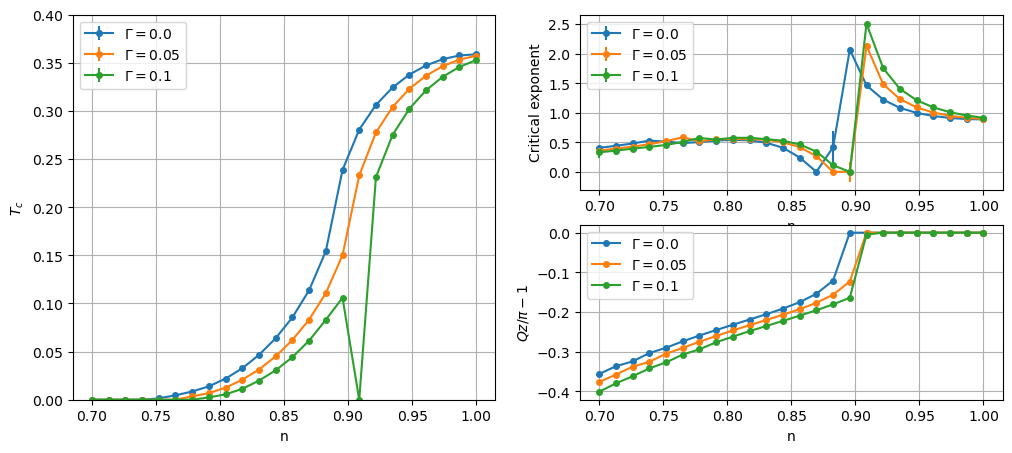

In [9]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma_list = [0., 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"$\Gamma={Gamma}$", markersize=4)

    color = line[0].get_color()
    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

    for a in ax:
        a.legend()

plt.show()

In [38]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 6)

nk = 100

Gamma = 0.025
tp_list = [0.05, 0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.005)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 'tp': tp,
                   'S_iwk_list': [1j*Gamma for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-04-27 11:32:19.460754
Starting serial run at: 2026-04-27 11:32:19.460862
Starting serial run at: 2026-04-27 11:32:19.476135


Starting serial run at: 2026-04-27 11:32:19.517090
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  5.5min


Starting serial run at: 2026-04-27 11:37:48.664854


Starting serial run at: 2026-04-27 11:37:49.502659
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  5.8min


Starting serial run at: 2026-04-27 11:43:46.625501


...

Starting serial run at: 2026-04-27 12:07:12.018905


Starting serial run at: 2026-04-27 12:07:24.946133


Starting serial run at: 2026-04-27 12:07:25.619399
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 17.2min


Starting serial run at: 2026-04-27 12:12:50.348300
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 17.7min remaining:  8.9min


Starting serial run at: 2026-04-27 12:13:25.034416
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 23.3min remaining:  6.1min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 23.5min remaining:  2.1min
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 23.6min finished


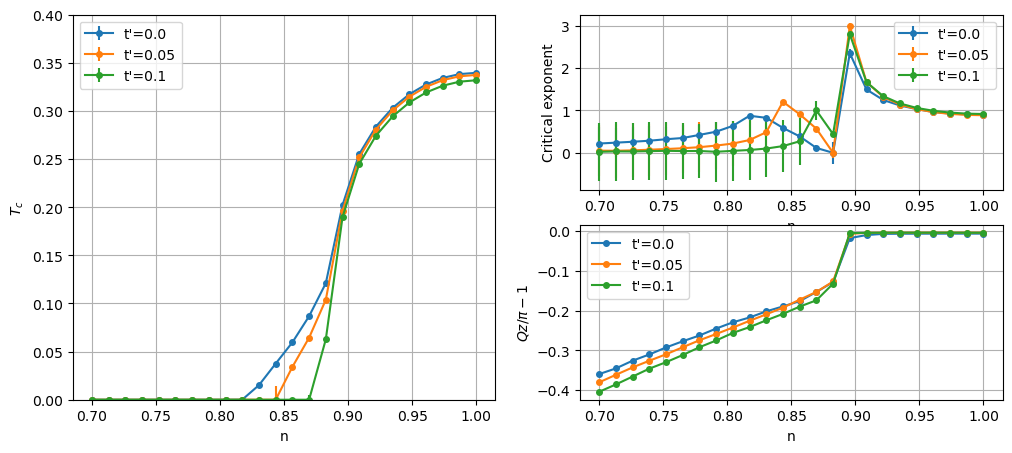

In [40]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma = 0.025
tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"t'={tp}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()


plt.savefig(f'{save_dir}/g{Gamma:.3f}postp.png', dpi=100)
plt.show()

SCBA: nk=100^2, beta=10.00, mu=0.0000, scatt. pot.=1.000
Converged at step 15 with diff = 4.495e-11
0.538182094297202


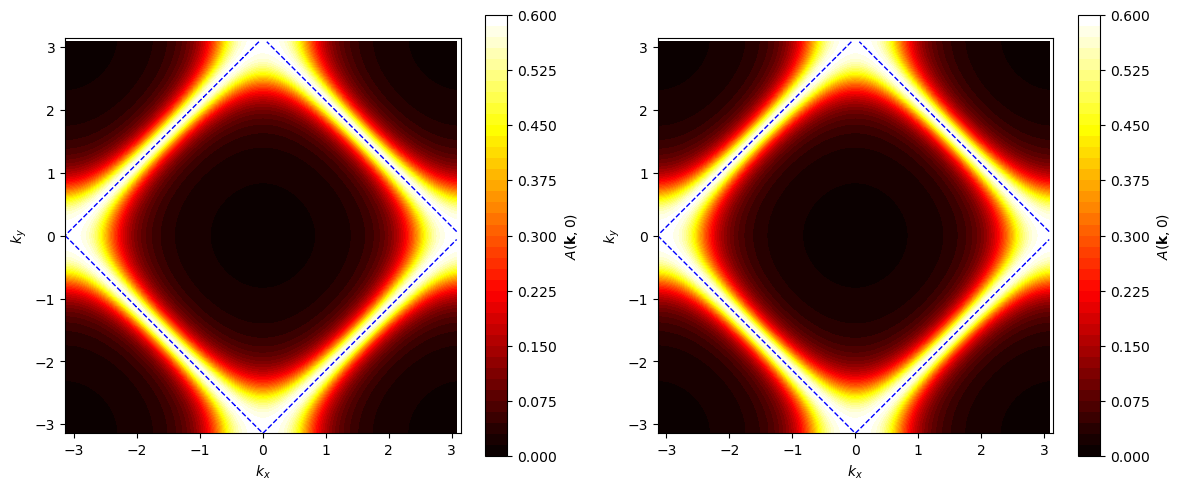

In [142]:
square = LATTICE(dim=2)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:,0,0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.1
n = 1
mu = get_mu(square.e_k, n, 1/T)
v = 1.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

square.get_e_k(nk=nk)
scba = SCBA(square, 1/T, nk=nk)
scba.run(v=v, n_goal=n, constant=True)
A1 = get_A_iw0k(scba.G_iwk).reshape(nk, nk)

S_iw = GfImFreq(beta=1/T, statistic='Fermion', n_points=scba.n_iw, target_shape=[1,1])
S_iw.data[:, 0, 0] = scba.S_iwk.data[:, :, 0, 0].mean(axis=1)

# Pade continue to real axis at omega=0
w_mesh = MeshReFreq(w_min=0.0, w_max=0.0, n_w=1)
S_w = GfReFreq(mesh=w_mesh, target_shape=[1,1])
S_w.set_from_pade(S_iw, n_points=60)

Gamma_eff = -S_w.data[0, 0, 0].imag
print(Gamma_eff)

A2 = (1/np.pi) * Gamma_eff / (Gamma_eff**2 + (eps - mu)**2)

vmax = max(A1.max(), A2.max())
vmin = min(A1.min(), A2.min())

ax = axes[0]
cf1 = axes[0].contourf(kx, ky, A1, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf1, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = axes[1].contourf(kx, ky, A2, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

SCBA: nk=100^2, beta=10.00, mu=0.0000, scatt. pot.=1.000
Converged at step 11 with diff = 4.054e-11
0.1379977548712244


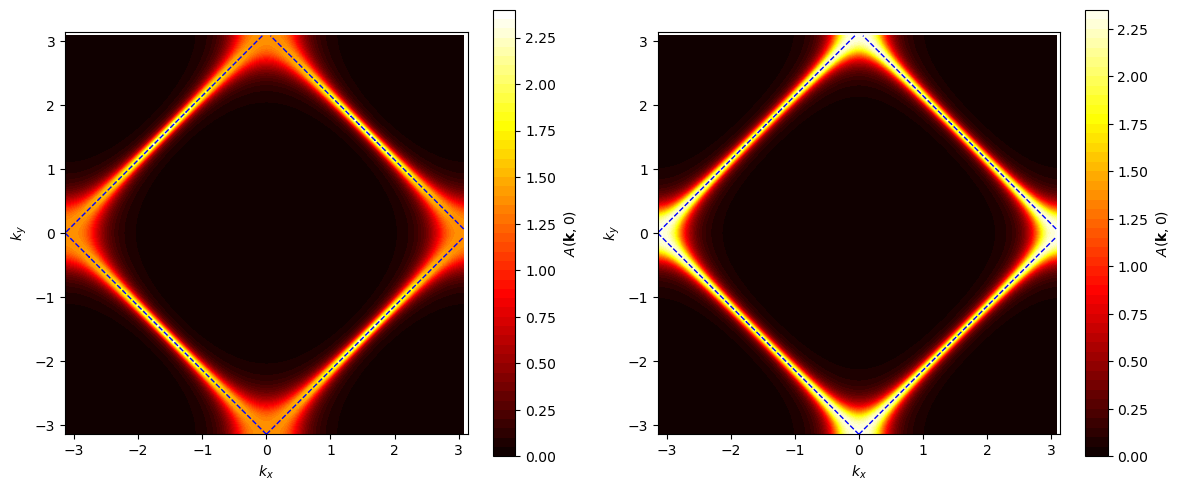

In [143]:
square = LATTICE(dim=2)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:,0,0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.1
n = 1
mu = get_mu(square.e_k, n, 1/T)
v = 1.
xi = 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

square.get_e_k(nk=nk)
scba = SCBA(square, 1/T, xi=xi, nk=nk)
scba.run(v=v, n_goal=n, constant=False)
A1 = get_A_iw0k(scba.G_iwk).reshape(nk, nk)

S_iw = GfImFreq(beta=1/T, statistic='Fermion', n_points=scba.n_iw, target_shape=[1,1])
S_iw.data[:,0,0] = scba.S_iwk.data[:,:,0,0].mean(axis=1)

# Pade continue to real axis at omega=0
w_mesh = MeshReFreq(w_min=0.0, w_max=0.0, n_w=1)
S_w = GfReFreq(mesh=w_mesh, target_shape=[1,1])
S_w.set_from_pade(S_iw, n_points=60)

Gamma_eff = -S_w.data[0,0,0].imag
print(Gamma_eff)

A2 = (1/np.pi) * Gamma_eff / (Gamma_eff**2 + (eps - mu)**2)

vmax = max(A1.max(), A2.max())
vmin = min(A1.min(), A2.min())

ax = axes[0]
cf1 = axes[0].contourf(kx, ky, A1, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf1, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = axes[1].contourf(kx, ky, A2, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()